In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
from pathlib import Path

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))


In [3]:
from lib.cea_lib.signal1D import*
from lib.cea_lib.general import*
from lib.cea_lib.data_loader import*
from lib.cea_lib.output import*
from lib.cea_lib.signal2D import*
from lib.cea_lib.physic import*
from lib.cea_lib.data_exporter import*
from lib.cea_lib.dataset_analysis import*
from lib.cea_lib.data_augmentation import*

# Visualisation

In [4]:
data, labels = load_RTCEA("../data/RTCEA_bimode.hdf5")
data = data[100:120, :, :]
time = labels[100:120, 1]

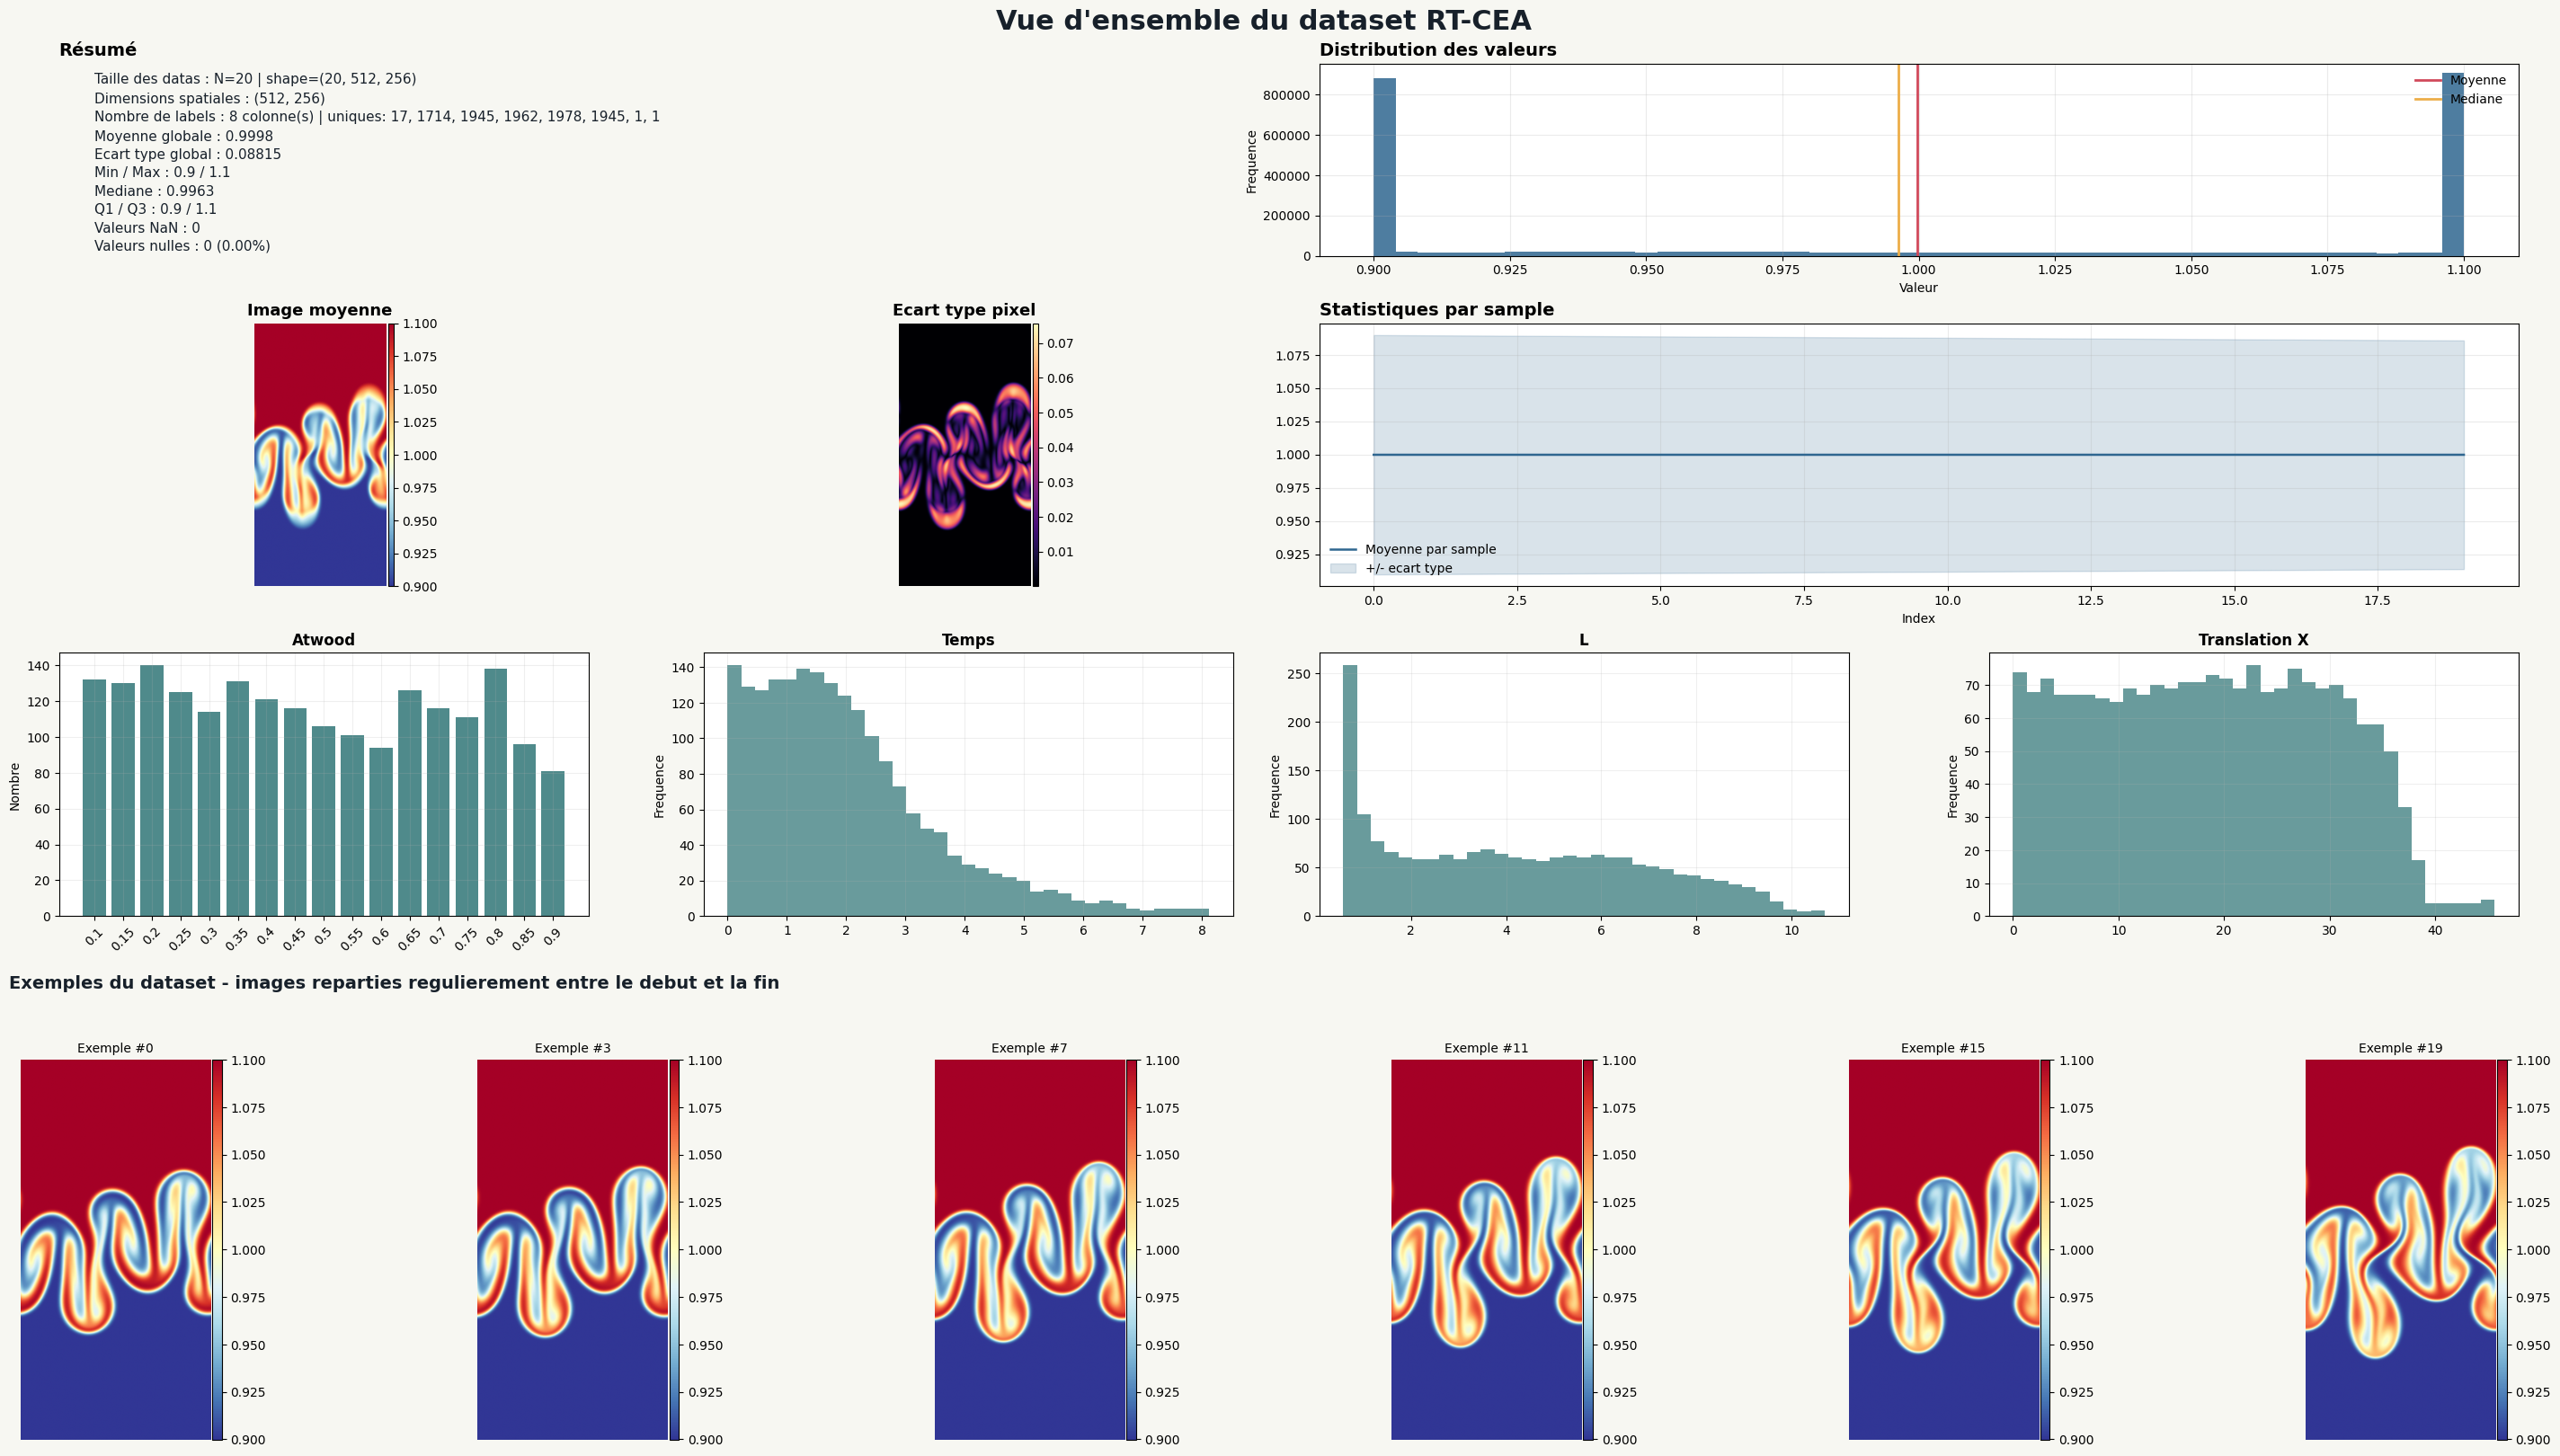

In [5]:
plot_dataset_overview(data, labels=labels, title="Vue d'ensemble du dataset RT-CEA", bins=50, save=False, save_path="../outputs/simple_bimode_overview.png")

## Augmantation

In [6]:
img = data[5]
lab = labels[5]
# imageplot(img, cmap='RdYlBu_r', colorbar=True)

(20, 512, 256)


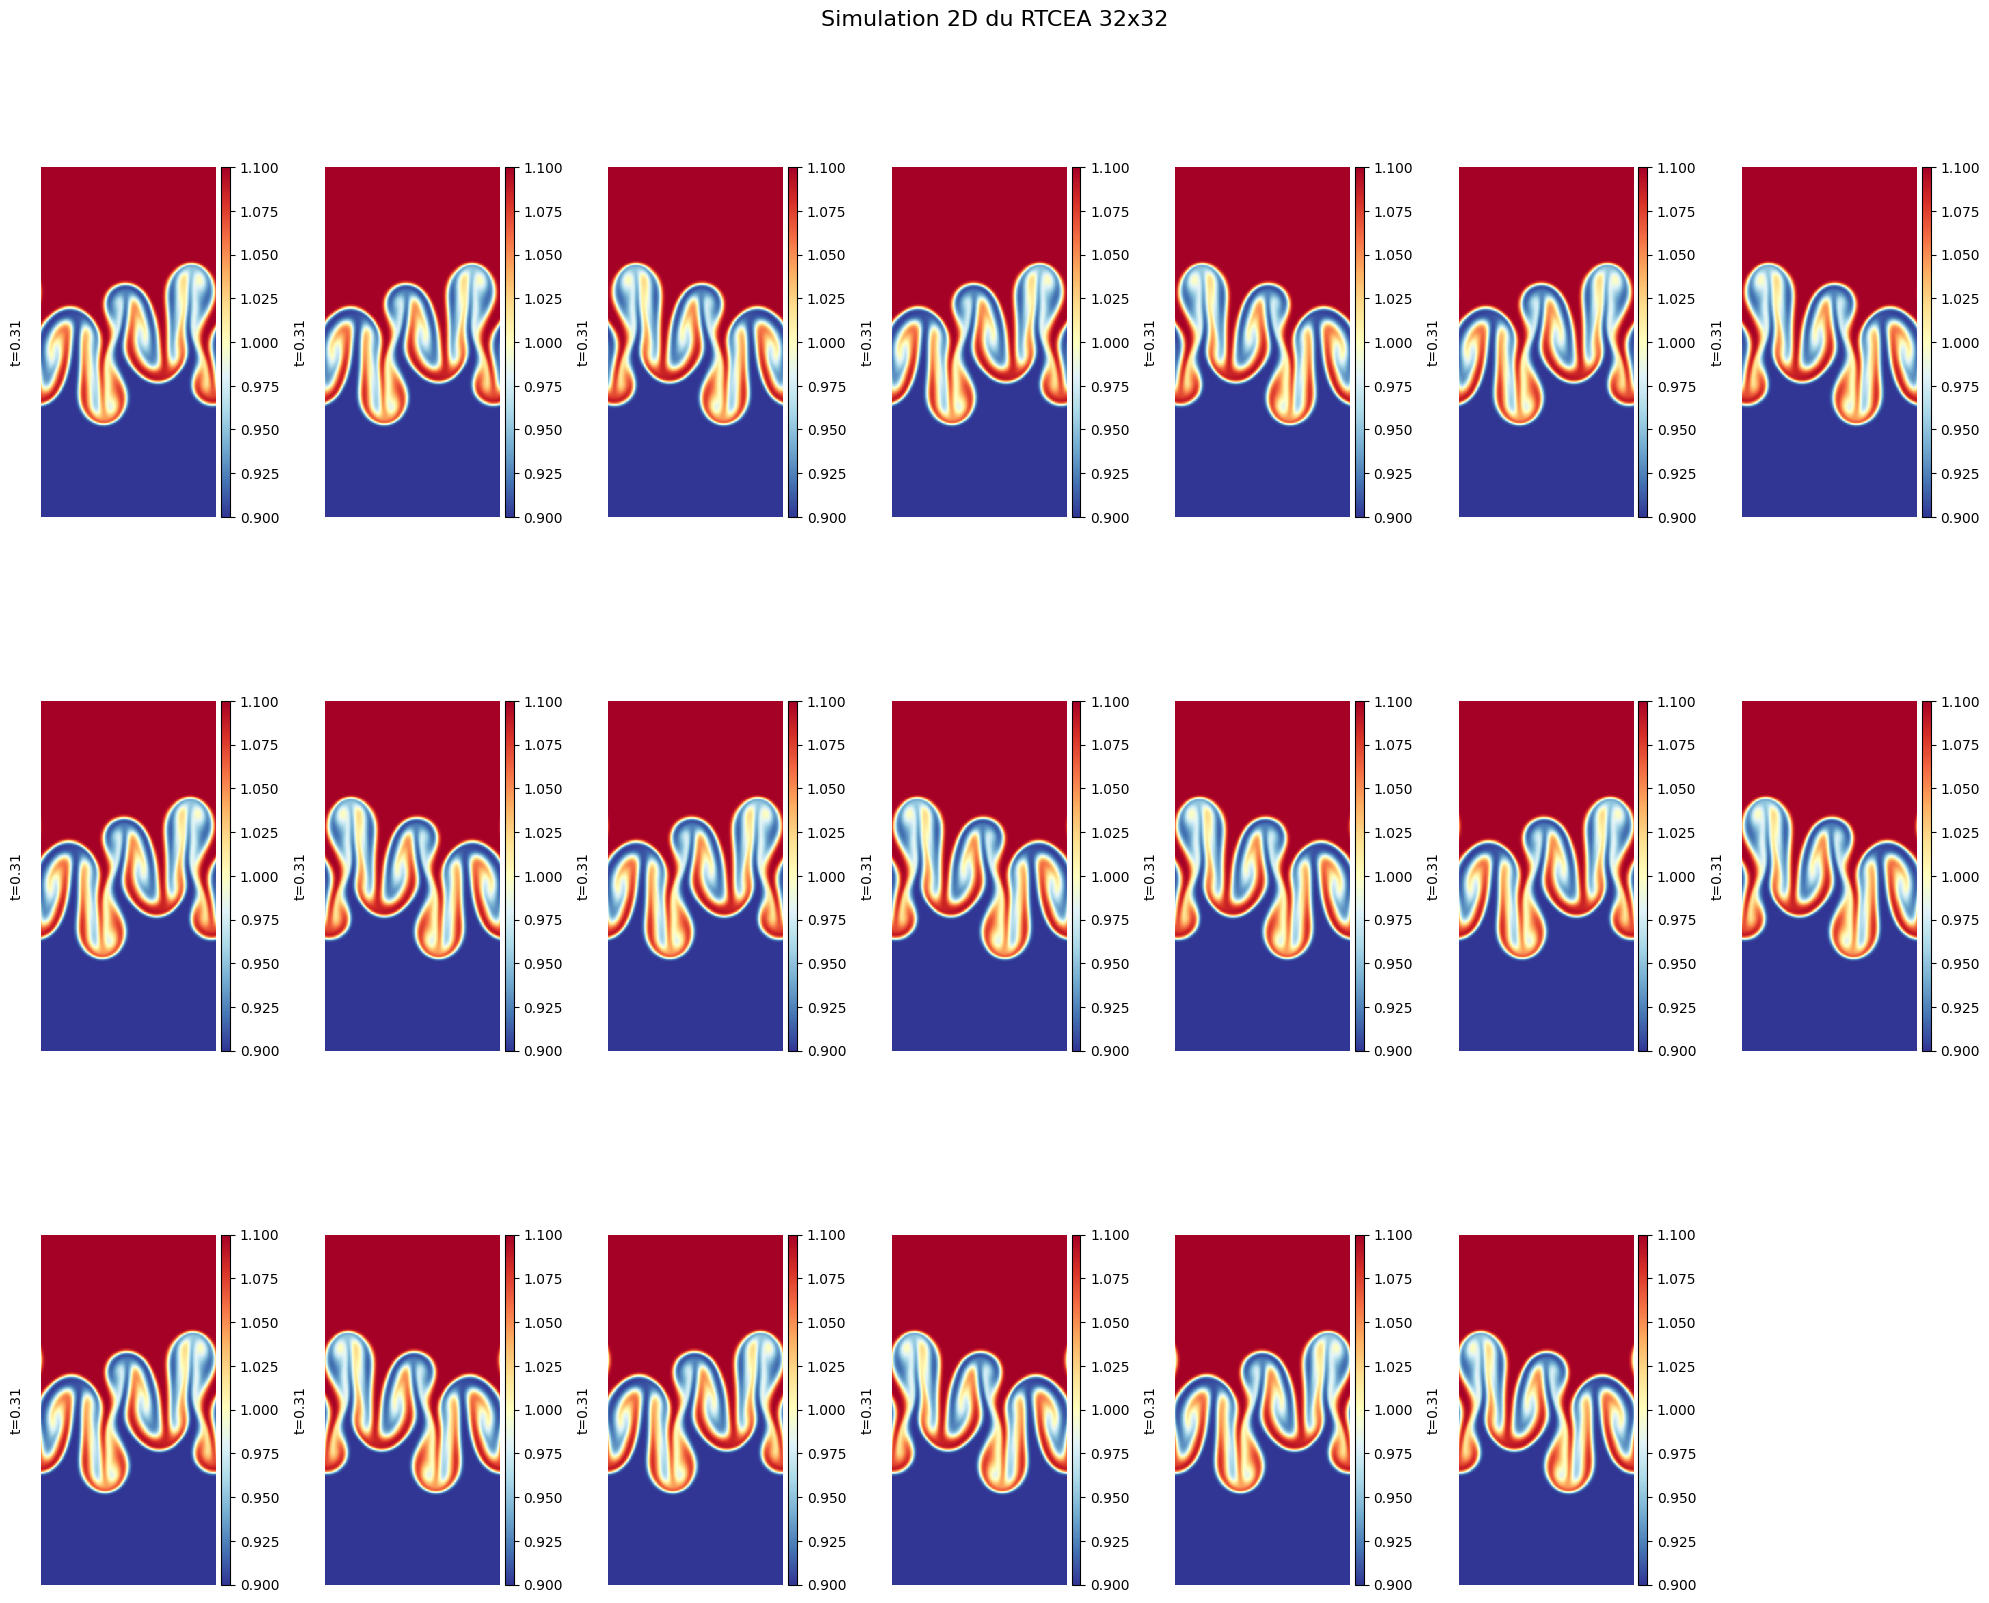

In [7]:
imgs, labs = augmentation(img, lab)
print(imgs.shape)  # (22, 32, 32)

t_labs = labs[:, 1]  # Extraire les labels de temps
plot_sim_2d_from_to(imgs, t_labs, 0, 19, 20, titre="Simulation 2D du RTCEA 32x32", save=False)


In [8]:
data_augmanted_images, data_augmented_labels = data_augmentater(data, labels, log=True)

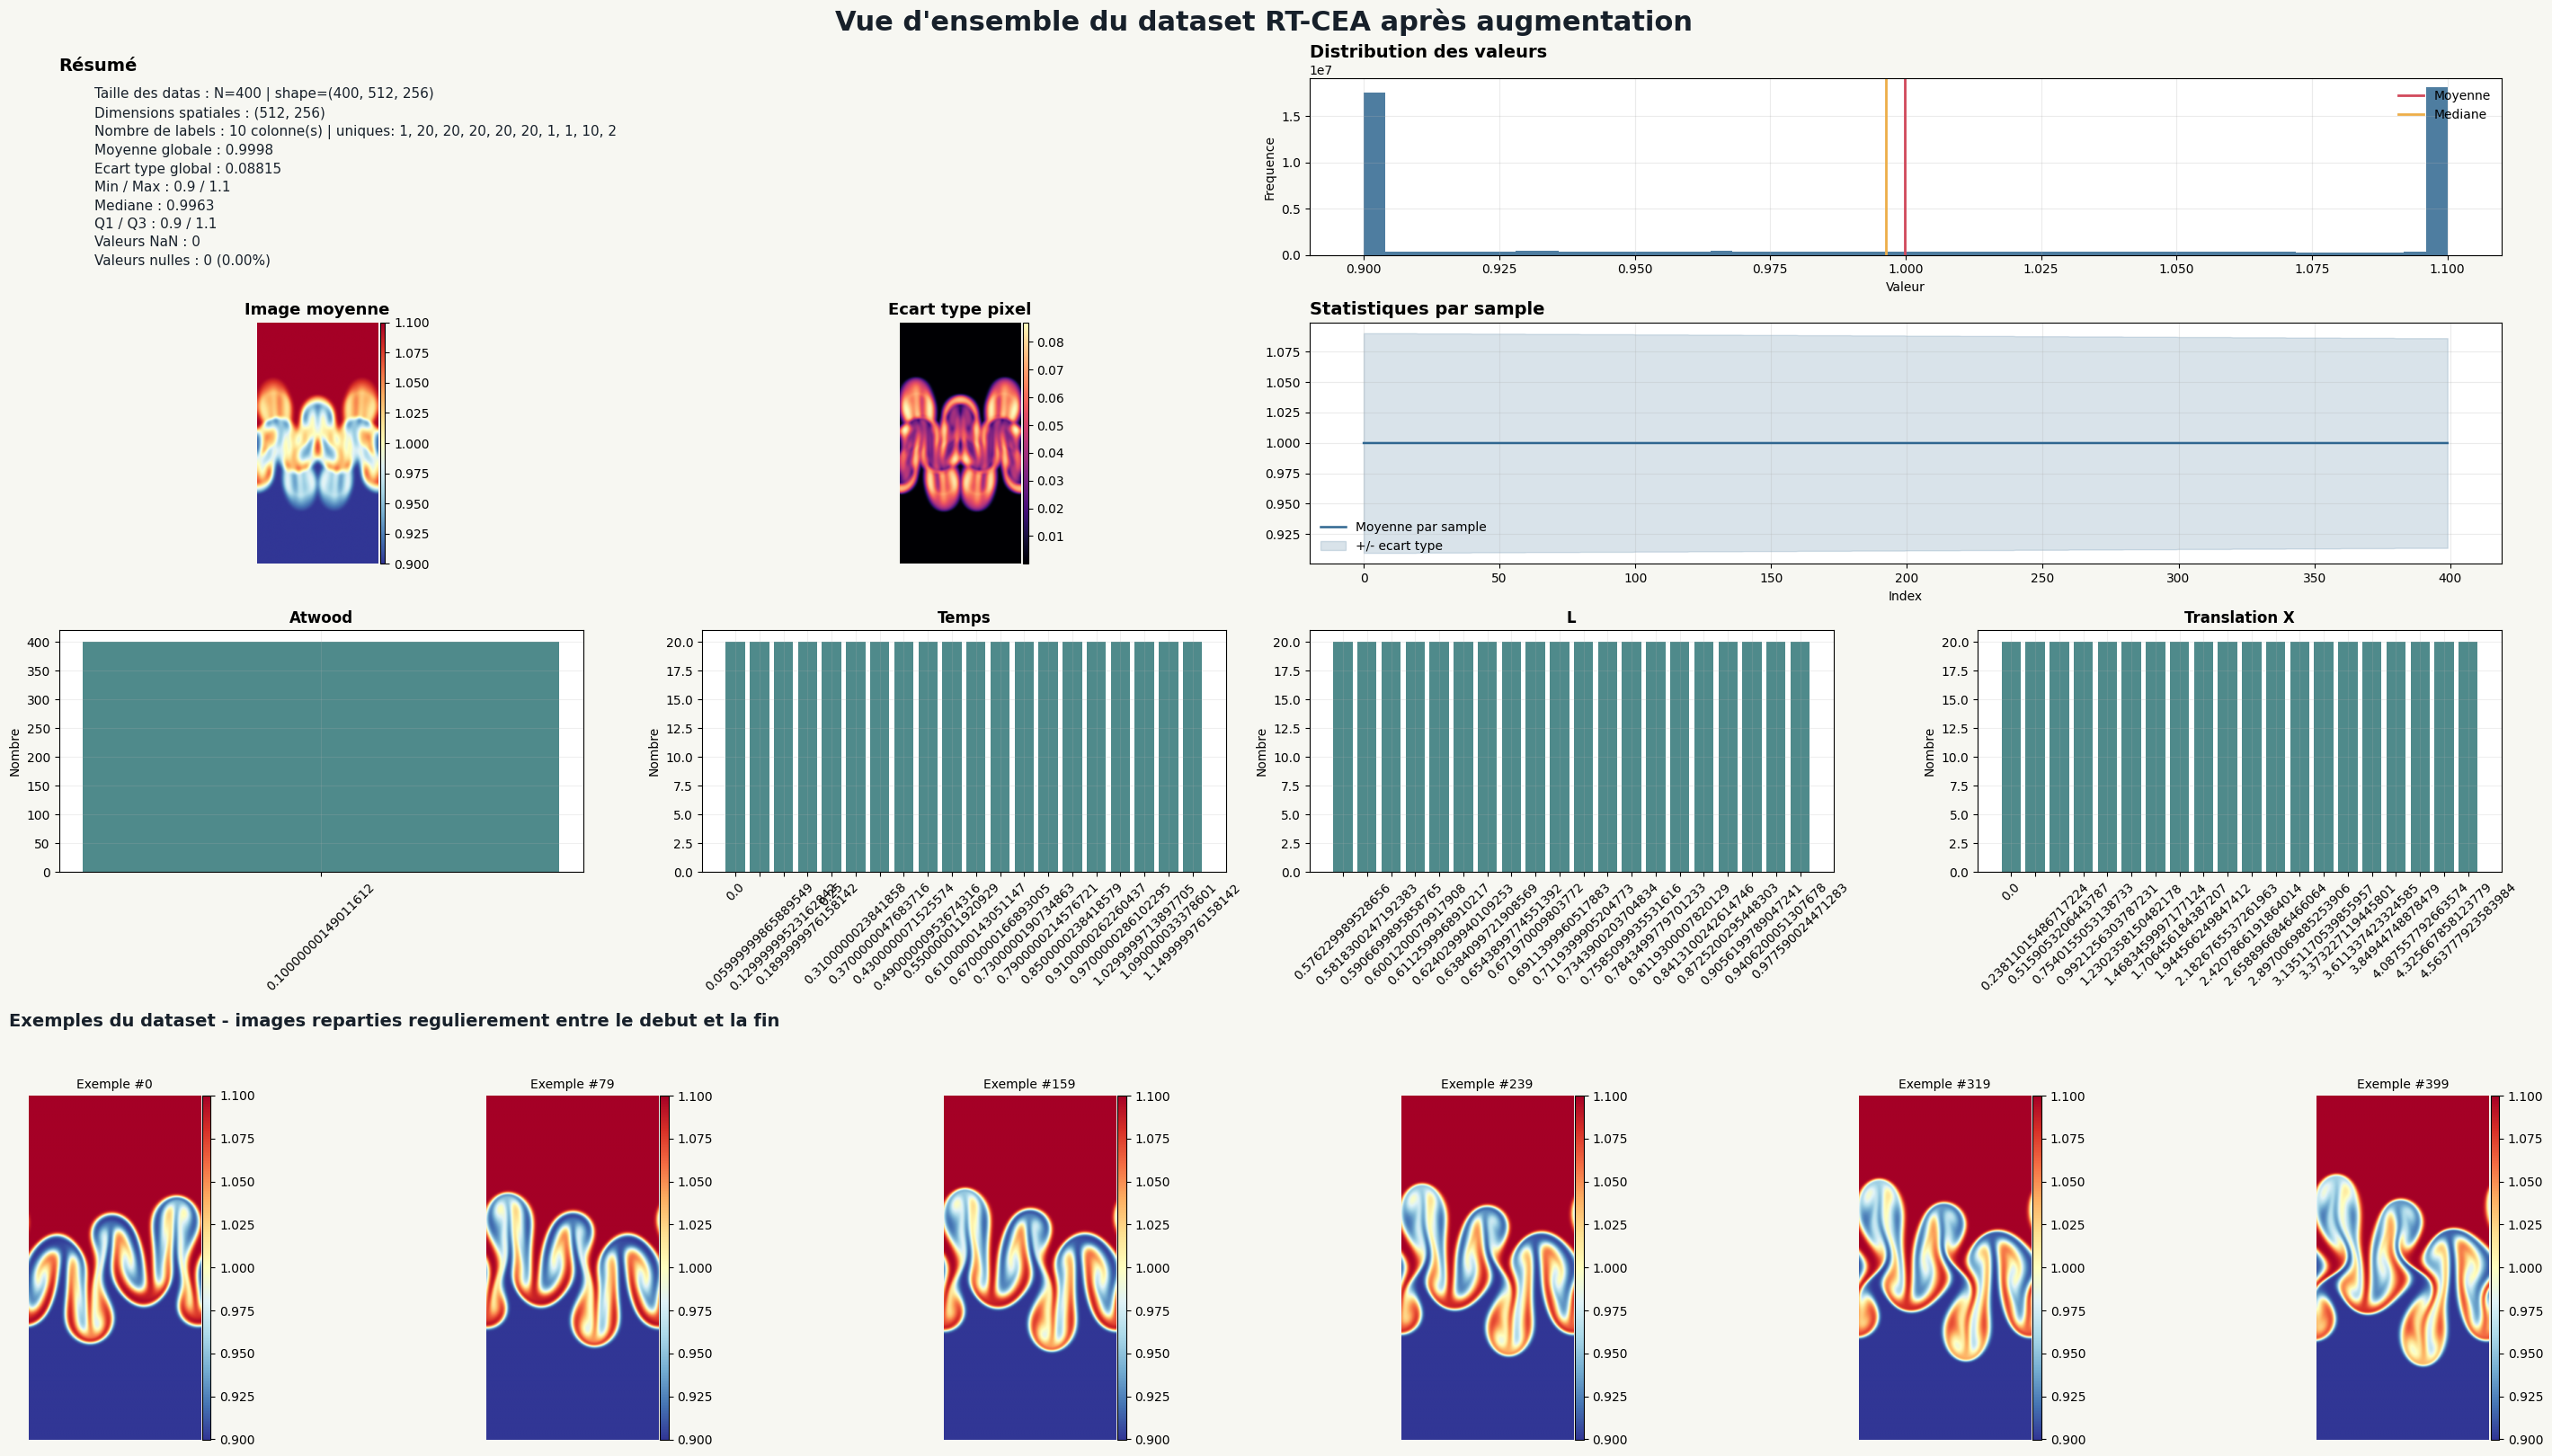

In [9]:
plot_dataset_overview(data_augmanted_images, labels=data_augmented_labels, title="Vue d'ensemble du dataset RT-CEA après augmentation", bins=50)

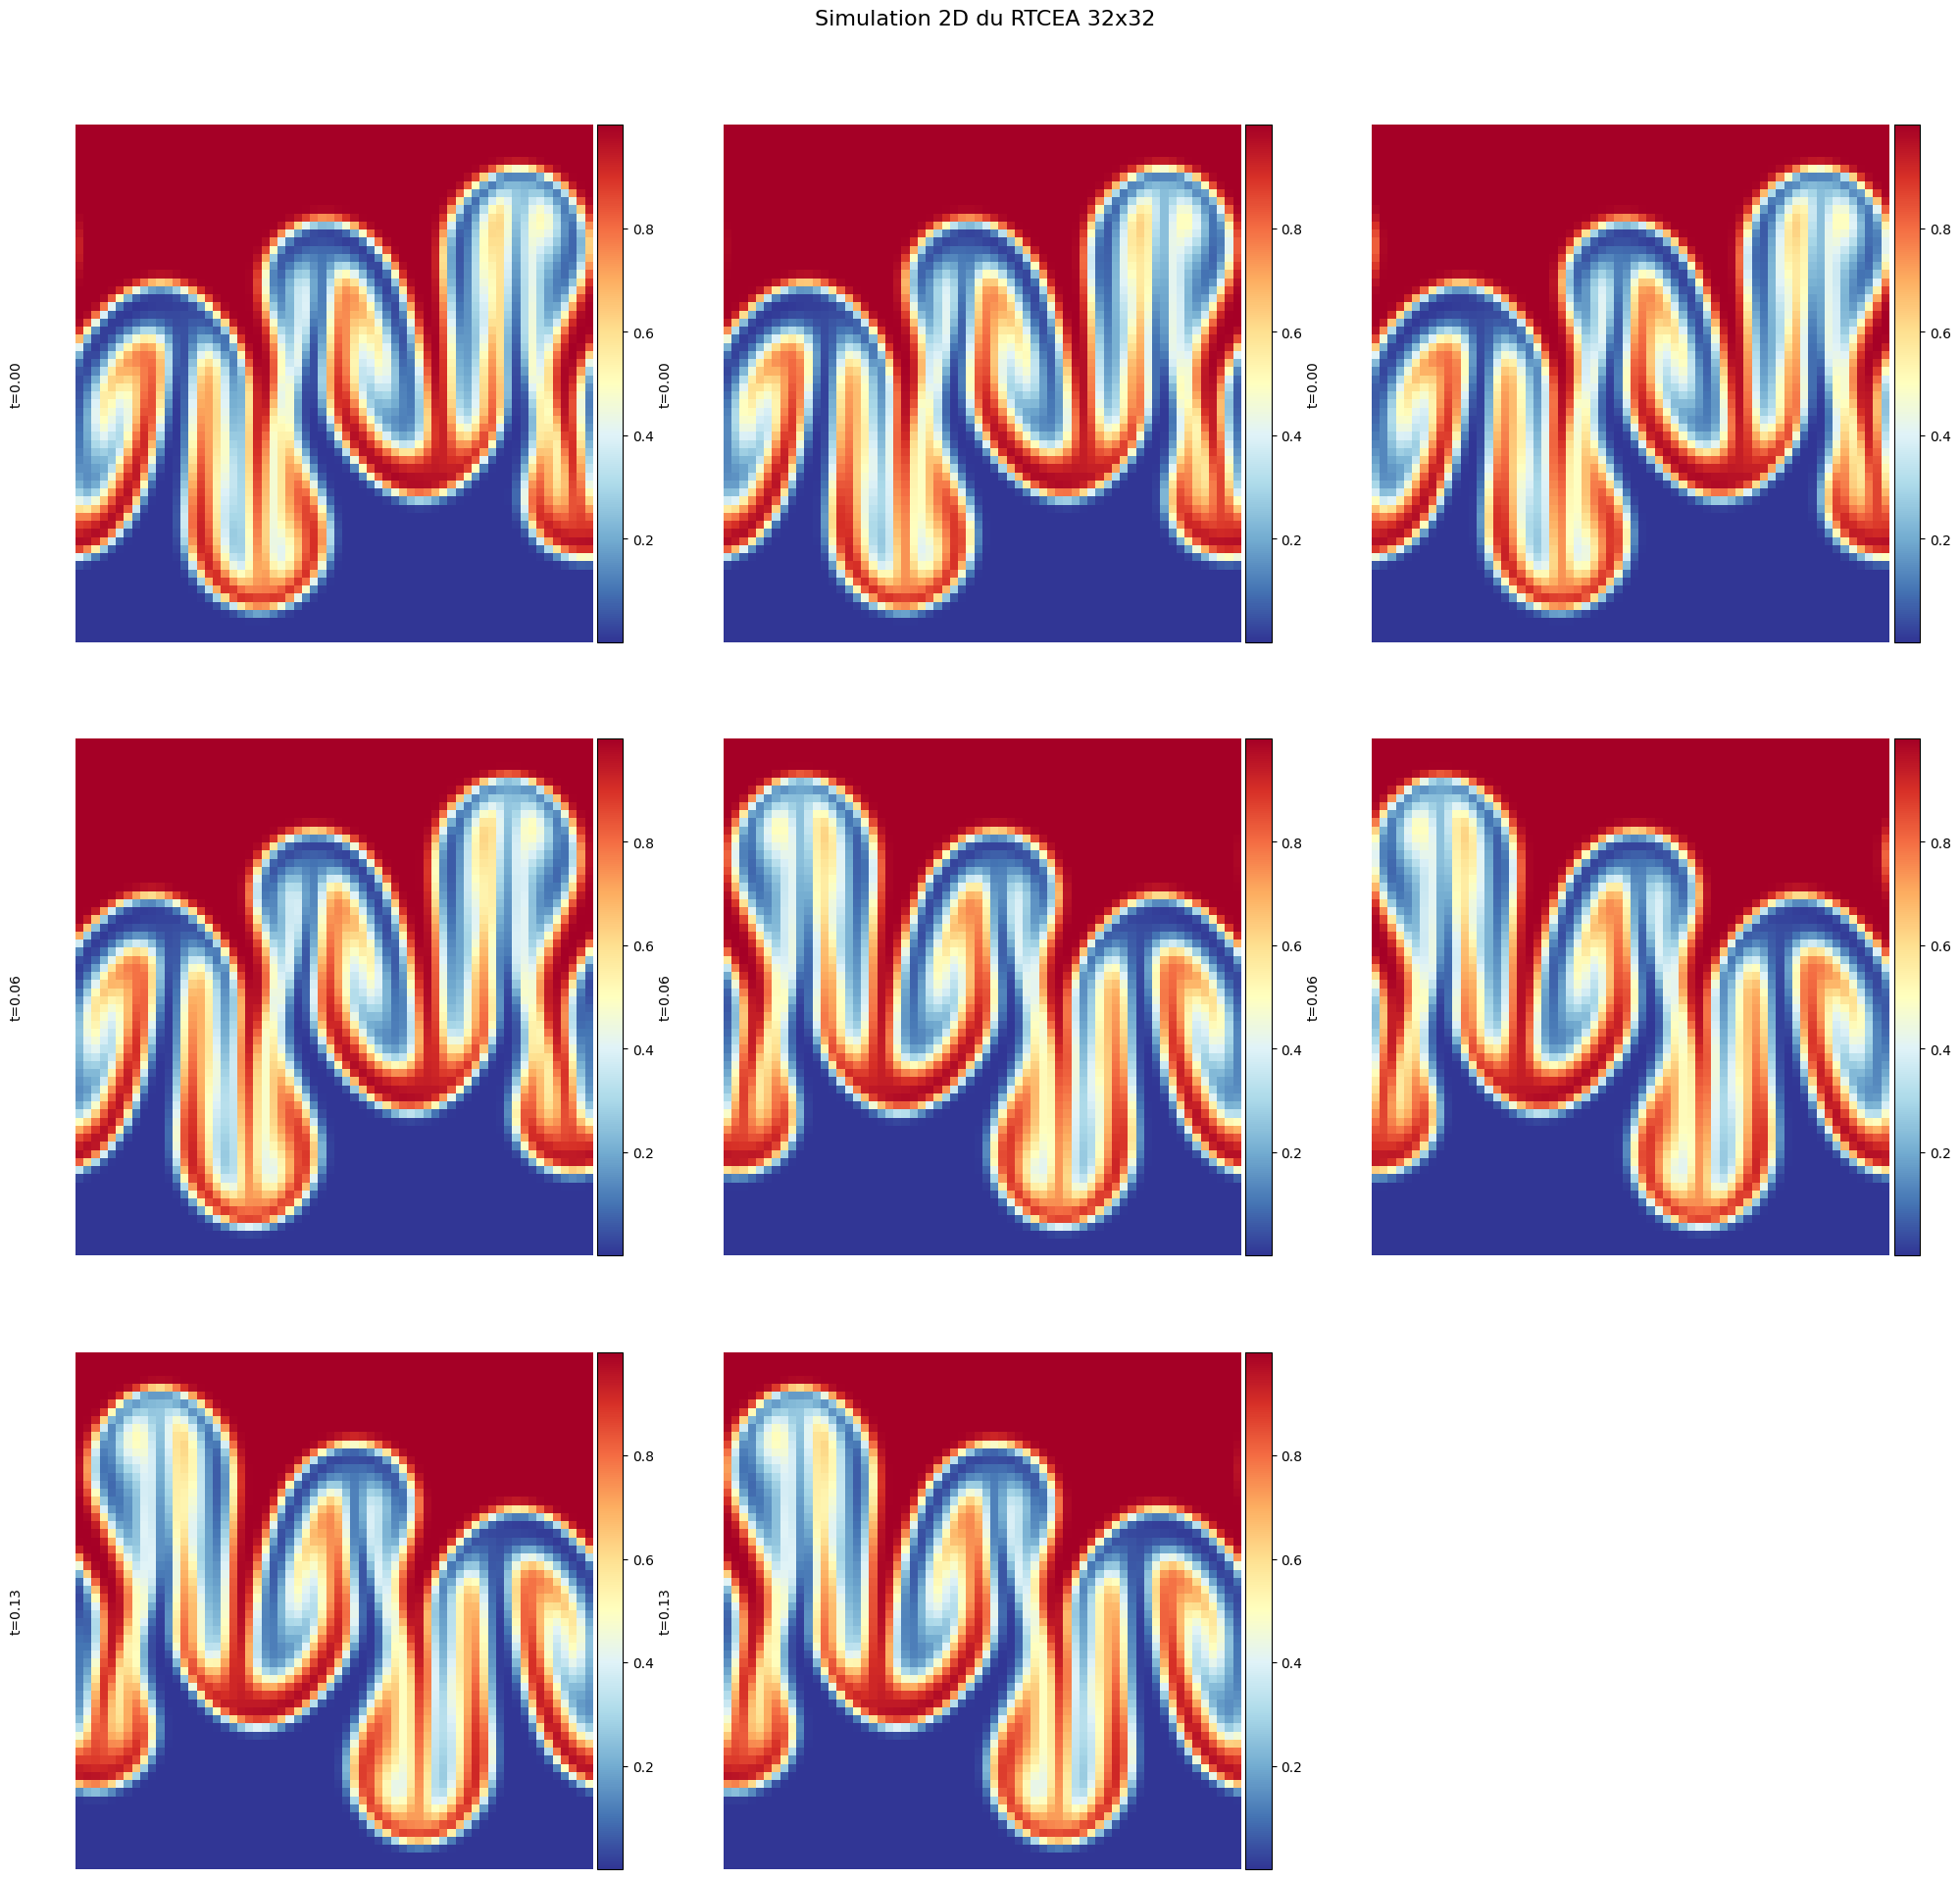

In [13]:
data_norm, new_labels = data_preprocessing(data_augmanted_images, data_augmented_labels, resize=64)
plot_sim_2d_from_to(data_norm, new_labels[:, 1], 0, 50, 8, titre="Simulation 2D du RTCEA 32x32", save=False)

In [11]:

def wavelet_non_lineaire_2d(x, n, wavelet, return_coeffs=False):
    """
    Compression non linéaire par ondelettes (sélection des n plus grands coefficients).

    Args:
        x (ndarray): image 2D
        n (int): nombre de coefficients conservés
        wavelet (str): type d'ondelette
        return_coeffs (bool): si True, retourne aussi les coefficients

    Returns:
        ndarray or tuple:
            - image reconstruite
            - (optionnel) coefficients et structures internes
    """
    coeffs = pywt.wavedec2(x, wavelet)
    arr, slices = pywt.coeffs_to_array(coeffs)

    flat = np.abs(arr).ravel()
    idx = np.argsort(flat)

    arr_f = np.zeros_like(arr)
    arr_f.flat[idx[-n:]] = arr.flat[idx[-n:]]

    coeffs_f = pywt.array_to_coeffs(arr_f, slices, output_format='wavedec2')
    x_rec = pywt.waverec2(coeffs_f, wavelet)

    if return_coeffs:
        return x_rec, coeffs_f, slices, arr_f
    else:
        return x_rec

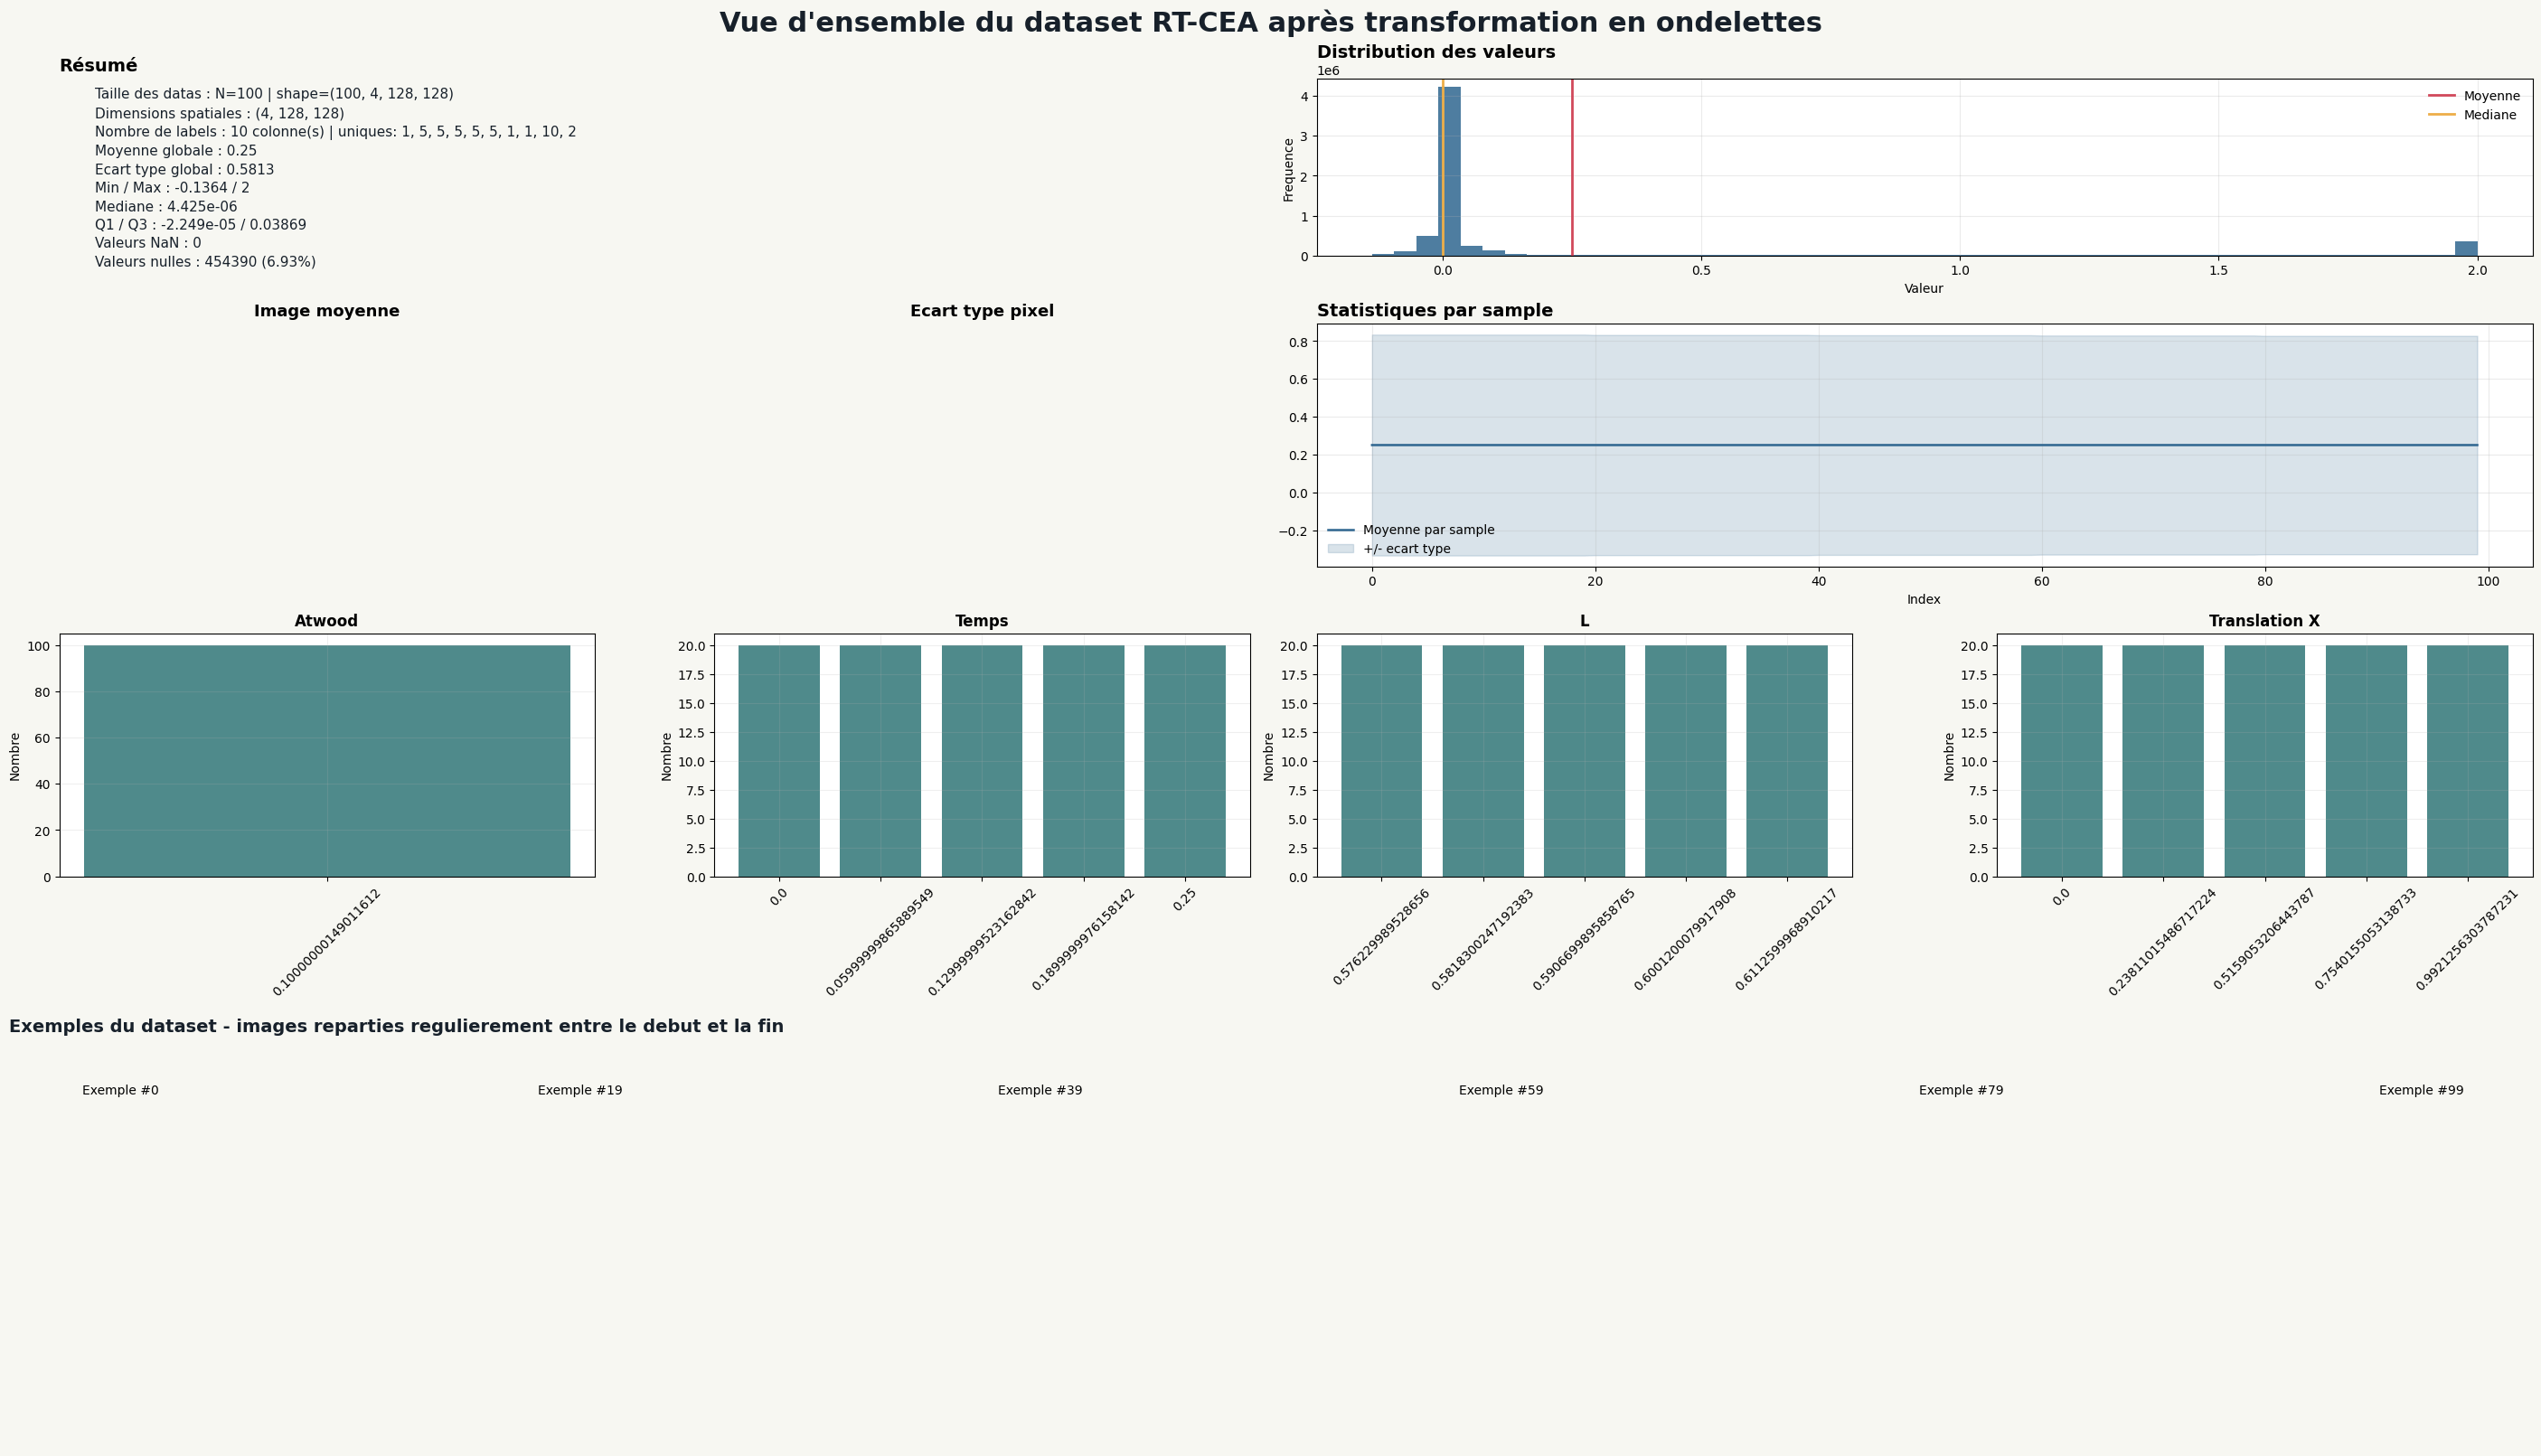

In [12]:
def data_wavelet_transform(data, wavelet='db1', level=1):
    """
    Applique la transformation en ondelettes à chaque image du dataset pour creer un dataset sous forme de coefficients d'ondelettes.

    Args:
        data (numpy.ndarray): Dataset d'images de forme (N, H, W).
        wavelet (str): Type d'ondelette à utiliser.
        level (int): Niveau de décomposition.

    Returns:
        numpy.ndarray: Dataset transformé en ondelettes de forme (N, J, C, H, W), avec J le nombre de niveaux de décomposition et C le nombre de canaux.
    """
    transformed_data = []
    for img in data:
        coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
        cA = coeffs[0]  # Approximation coefficients
        cH = coeffs[1][0]  # Horizontal detail coefficients
        cV = coeffs[1][1]  # Vertical detail coefficients
        cD = coeffs[1][2]  # Diagonal detail coefficients
        transformed_img = np.stack([cA, cH, cV, cD], axis=0)  # Stack coefficients along a new axis
        transformed_data.append(transformed_img)
    return np.array(transformed_data)

wave_data = data_wavelet_transform(data_norm, wavelet='db1', level=1)
plot_dataset_overview(wave_data, labels=new_labels, title="Vue d'ensemble du dataset RT-CEA après transformation en ondelettes", bins=50, save=False, save_path="../outputs/wavelet_bimode_overview.png")